# Restaurant Recommendation System Based on User Reviews

Group - 13

Team Members: Bei Su, Yanxu,Yang, Chenhui Shen, Zeran Huang

# Introduction

**Problem Statement**

Yelp, as one of the largest review platforms, offers a wealth of customer opinions that could drive strategic decisions, yet its sheer volume and complexity make it difficult to derive clear, targeted insights.

Our project addresses this challenge by focusing on the food and beverage sector. Initially, we applied unsupervised learning techniques (such as PCA and clustering) to the entire Yelp dataset, but the results lacked detailed, actionable insights due to high dimensionality and noise. To overcome this, we restructured the project by merging the three raw Yelp datasets into a unified df_full_dataset and implementing a two-step filtering process:

 1. Food Category Extraction: We split the categories column to isolate 220 food-related categories from a total of 1312 unique categories, forming a focused food_categories dataset.
 2. Key City Selection: We then selected the top three cities with the highest review counts to ensure that our analysis is based on representative, high-volume data, while also reducing computational load.





**Source**: The dataset, publicly released by the yelp Open Dataset portal, provides real data related to merchants, including reviews, photos, check-ins, and attributes such as hours of operation, parking, and ambiance.

Dataset URL:https://business.yelp.com/data/resources/open-dataset/

**Data Dictionary**:

The analysis contains three datasets, Business, user, and review.The three datasets provide real-world data related to businesses including reviews, photos, check-ins, and attributes It provides real-world data related to businesses including reviews, photos, check-ins, and attributes like hours, parking availability, and ambience.

Dataset size: business = 113.4 MB, user = 3.13 GB, review = 4.98 GB

Number of records: business = rows, user = rows, review = rows

Number of attributes: business = columns, user = columns, review = columns

# Data Cleaning & Preprocessing

In [2]:
!pip install gcsfs

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
gcs_file_path = '/content/drive/MyDrive/yelp_academic_dataset_business.json'
df_business = pd.read_json(gcs_file_path, lines=True)
print(df_business.head())
print(f"df_business shape: {df_business.shape}")

              business_id                      name  \
0  Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
1  mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
2  tUFrWirKiKi_TAnsVWINQQ                    Target   
3  MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
4  mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   

                           address           city state postal_code  \
0           1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
1  87 Grasso Plaza Shopping Center         Affton    MO       63123   
2             5255 E Broadway Blvd         Tucson    AZ       85711   
3                      935 Race St   Philadelphia    PA       19107   
4                    101 Walnut St     Green Lane    PA       18054   

    latitude   longitude  stars  review_count  is_open  \
0  34.426679 -119.711197    5.0             7        0   
1  38.551126  -90.335695    3.0            15        1   
2  32.223236 -110.880452    3.5            22        0   
3  39.9555

In [5]:
gcs_file_path = '/content/drive/MyDrive/yelp_academic_dataset_review.json'
chunk_size = 100000
chunks = pd.read_json(gcs_file_path, lines=True, chunksize=chunk_size)
df_review = pd.concat(chunks, ignore_index=True)
print(f"df_review shape: {df_review.shape}")
print(df_review.head(10))

df_review shape: (6990280, 9)
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   
5  JrIxlS1TzJ-iCu79ul40cQ  eUta8W_HdHMXPzLBBZhL1A  04UD14gamNjLY0IDYVhHJg   
6  6AxgBCNX_PNTOxmbRSwcKQ  r3zeYsv1XFBRA4dJpL78cw  gmjsEdUsKpj9Xxu6pdjH0g   
7  _ZeMknuYdlQcUqng_Im3yg  yfFzsLmaWF2d4Sr0UNbBgg  LHSTtnW3YHCeUkRDGyJOyw   
8  ZKvDG2sBvHVdF5oBNUOpAQ  wSTuiTk-sKNdcFyprzZAjg  B5XSoSG3SfvQGtKEGQ1tSQ   
9  pUycOfUwM8vqX7KjRRhUEA  59MxRhNVhU9MYndMkz0wtw  gebiRewfieSdtt17PTW6Zg   

   stars  useful  funny  cool  \
0      3       0      0     0   
1      5       1      0     1   
2      3       0      0

In [6]:
import pandas as pd

gcs_user_file_path = '/content/drive/MyDrive/yelp_academic_dataset_user.json'
chunk_size = 100000
user_chunks = pd.read_json(gcs_user_file_path, lines=True, chunksize=chunk_size)
df_user = pd.concat(user_chunks, ignore_index=True)

print(f"df_user shape: {df_user.shape}")
print(df_user.head(10))

df_user shape: (1987897, 22)
                  user_id      name  review_count        yelping_since  \
0  qVc8ODYU5SZjKXVBgXdI7w    Walker           585  2007-01-25 16:47:26   
1  j14WgRoU_-2ZE1aw1dXrJg    Daniel          4333  2009-01-25 04:35:42   
2  2WnXYQFK0hXEoTxPtV2zvg     Steph           665  2008-07-25 10:41:00   
3  SZDeASXq7o05mMNLshsdIA      Gwen           224  2005-11-29 04:38:33   
4  hA5lMy-EnncsH4JoR-hFGQ     Karen            79  2007-01-05 19:40:59   
5  q_QQ5kBBwlCcbL1s4NVK3g      Jane          1221  2005-03-14 20:26:35   
6  cxuxXkcihfCbqt5Byrup8Q       Rob            12  2009-02-24 03:09:06   
7  E9kcWJdJUHuTKfQurPljwA      Mike           358  2008-12-11 22:11:56   
8  lO1iq-f75hnPNZkTy3Zerg  Rachelle            40  2008-12-29 22:40:56   
9  AUi8MPWJ0mLkMfwbui27lg      John           109  2010-01-07 18:32:04   

   useful  funny   cool                                              elite  \
0    7217   1259   5994                                               2007   


**Check missing value**

**BUSINESS DATA**

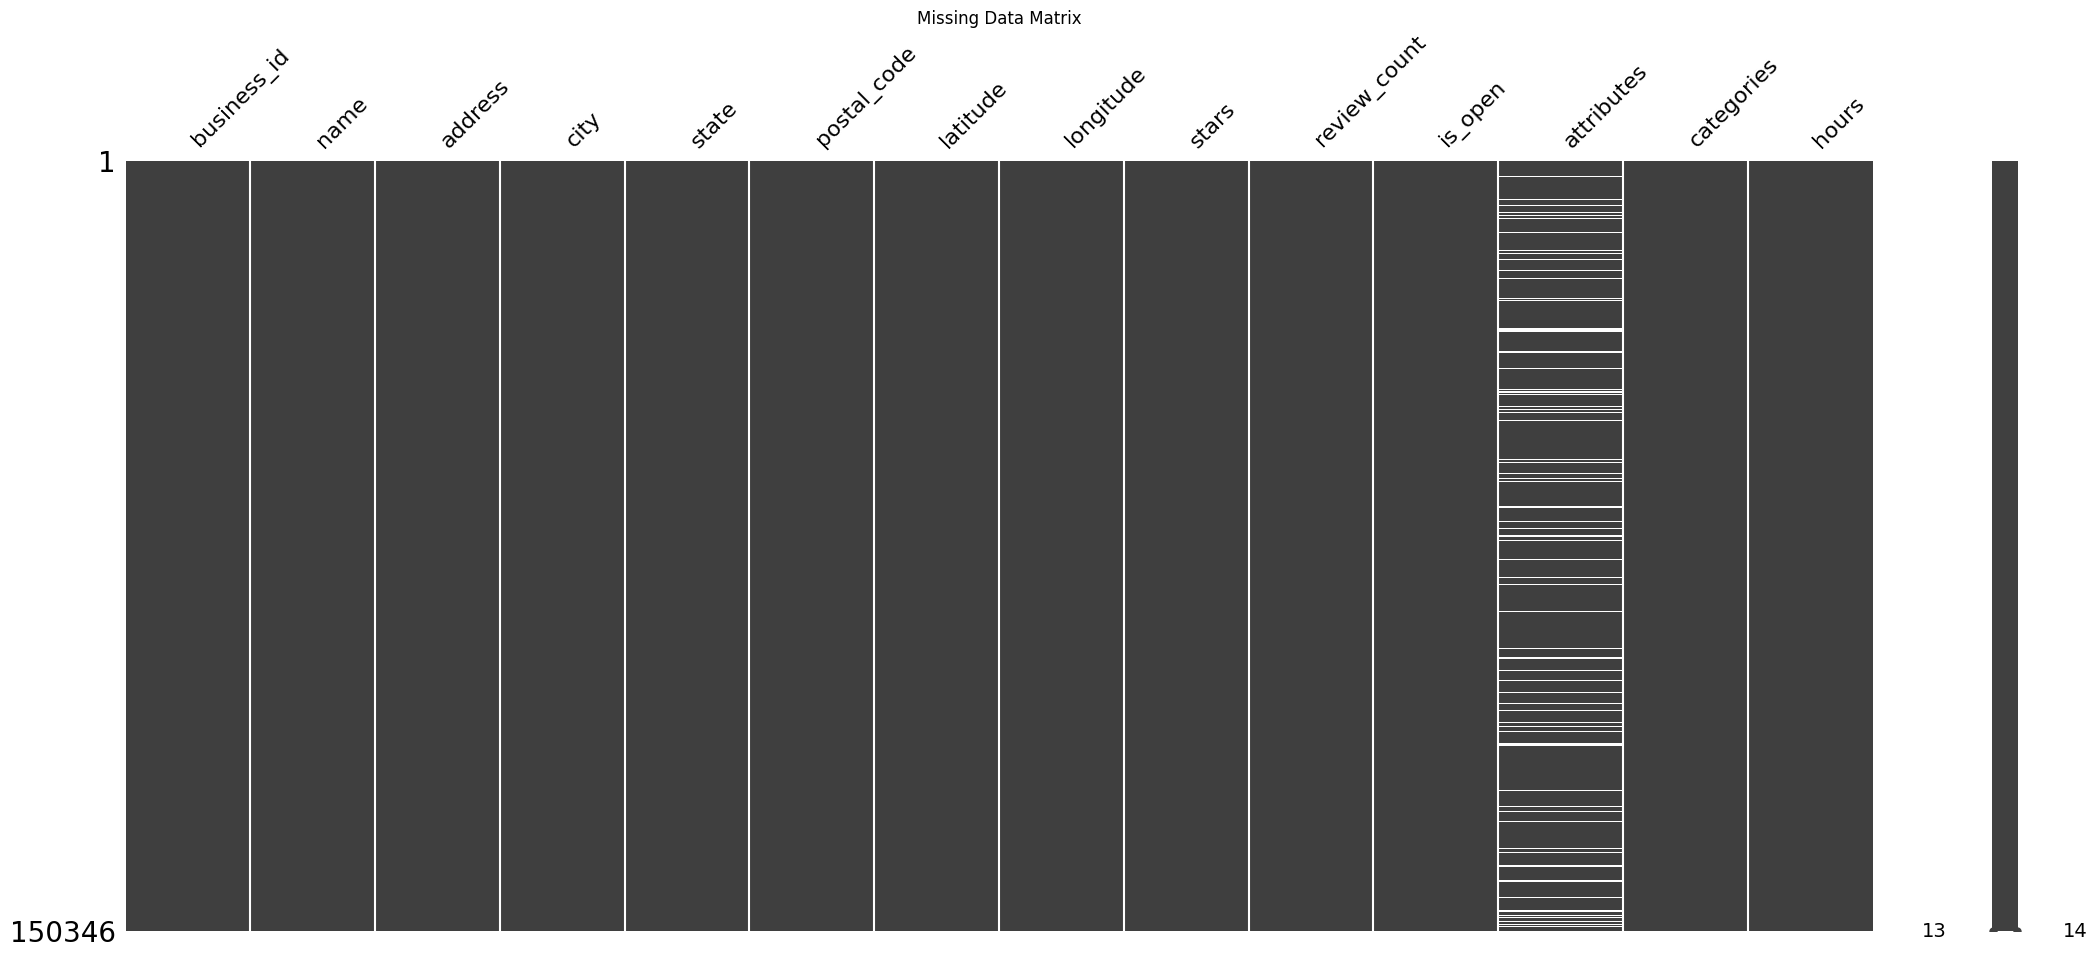

In [27]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df_business)
plt.title("Missing Data Matrix")
plt.show()

**User DATA**

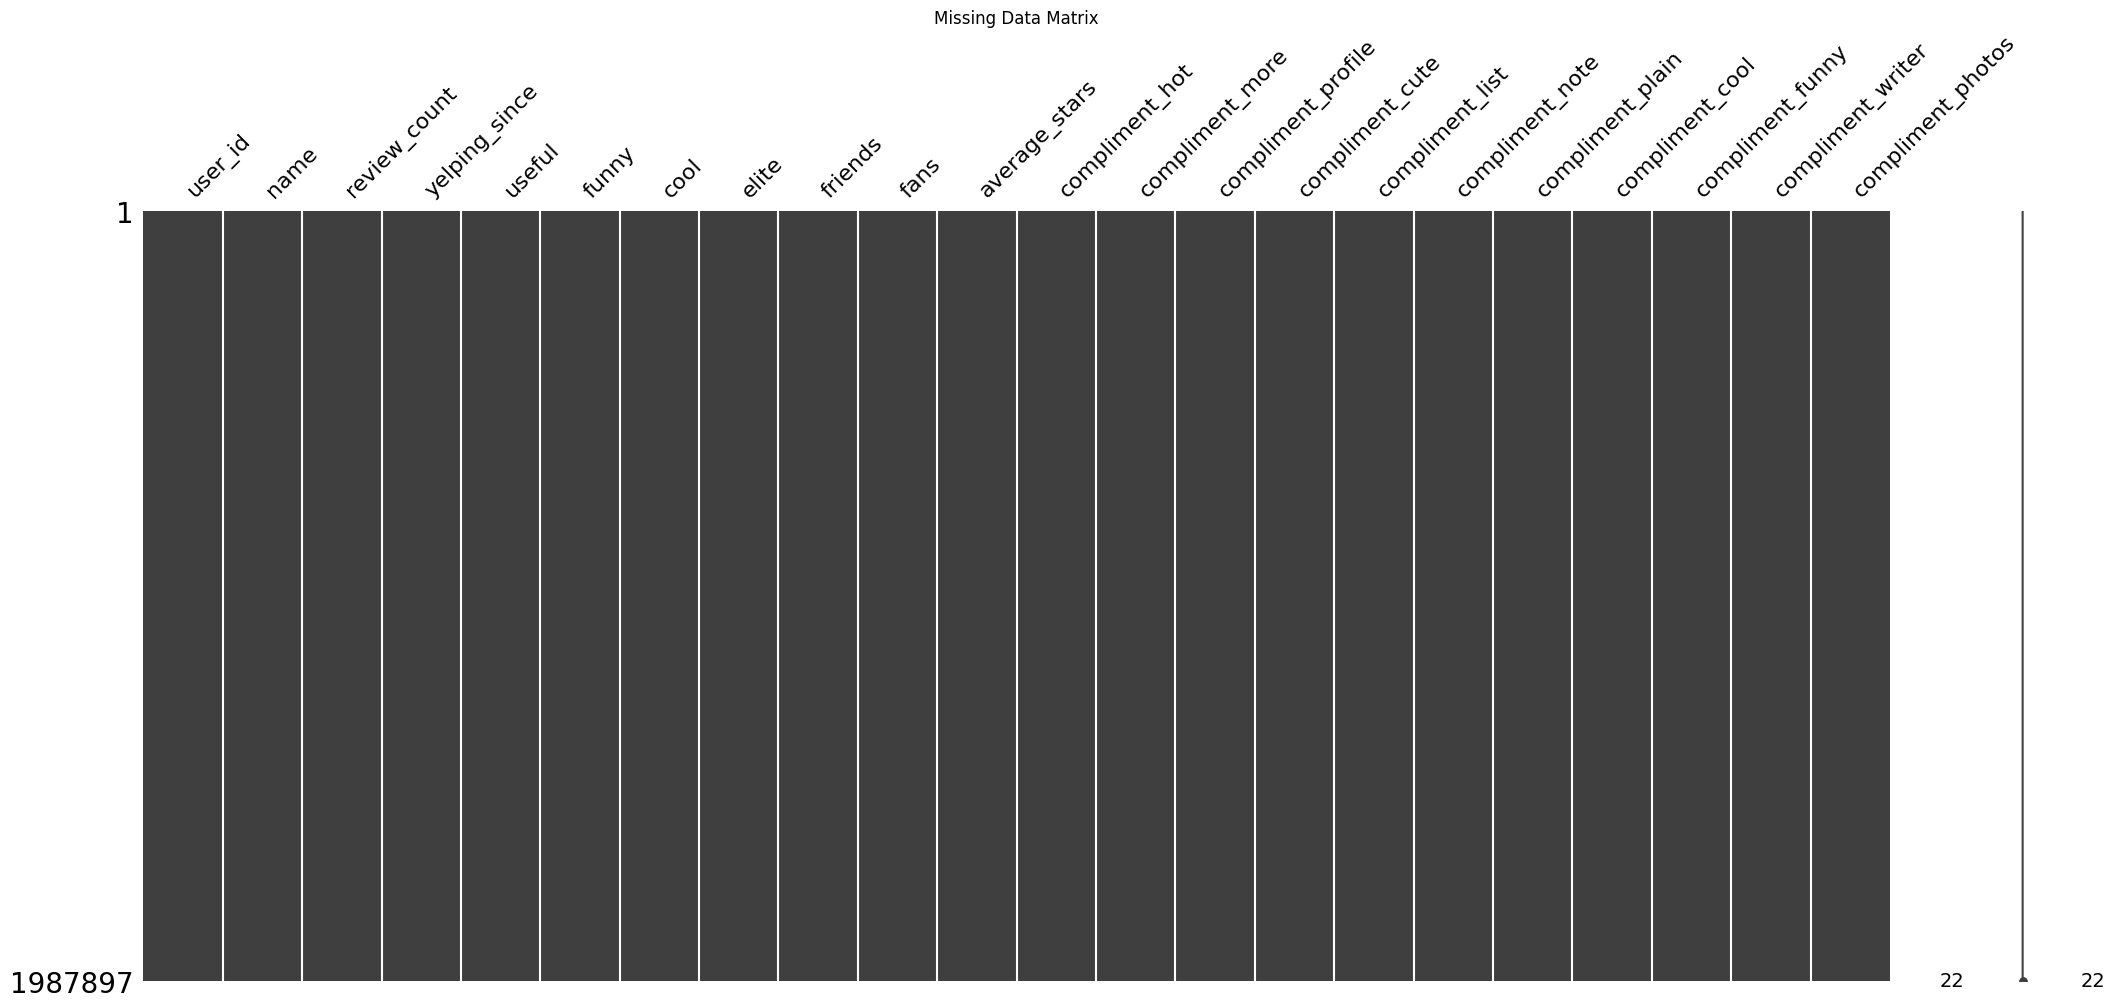

In [28]:
msno.matrix(df_user)
plt.title("Missing Data Matrix")
plt.show()

**REVIEW DATA**

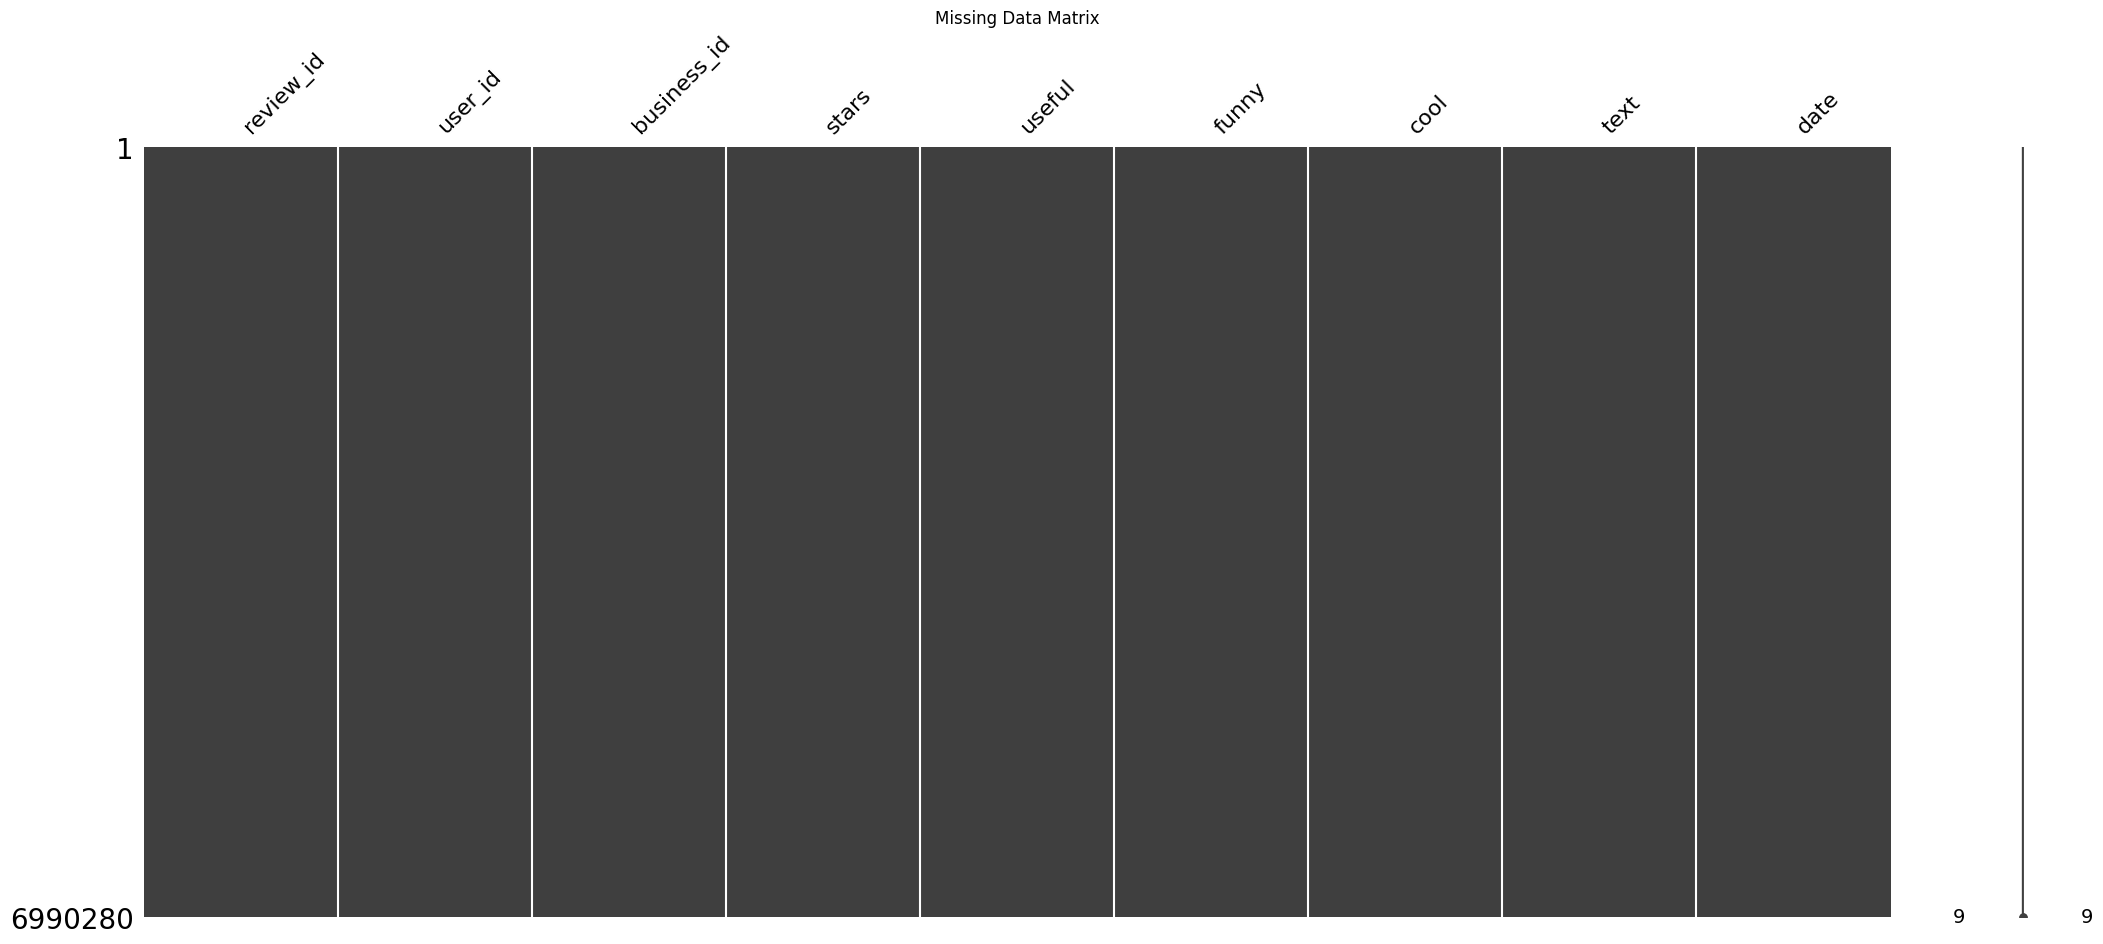

In [29]:
msno.matrix(df_review)
plt.title("Missing Data Matrix")
plt.show()

In [7]:
print("Business data missing value：")
print(df_business.isnull().sum())
print("\nReview missing value：")
print(df_review.isnull().sum())
print("\nUser missing value：")
print(df_user.isnull().sum())

Business data missing value：
business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes      13744
categories        103
hours           23223
dtype: int64

Review missing value：
review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64

User missing value：
user_id               0
name                  0
review_count          0
yelping_since         0
useful                0
funny                 0
cool                  0
elite                 0
friends               0
fans                  0
average_stars         0
compliment_hot        0
compliment_more       0
compliment_profile    0
compliment_cute       0
compliment_list       0
compliment_note       0
compliment_plain      0
complime

**Drop missing value**

In [8]:
df_business['categories'] = df_business['categories'].fillna("Unknown")
df_business['hours'] = df_business['hours'].fillna("Not Available")

print(df_business[['categories', 'hours']].isnull().sum())

categories    0
hours         0
dtype: int64


**Determine ID uniqueness for categorization**

In [9]:
df_business.drop_duplicates(subset=['business_id'], inplace=True)
df_review.drop_duplicates(subset=['review_id'], inplace=True)
df_user.drop_duplicates(subset=['user_id'], inplace=True)

**Standardized date format**

In [10]:
df_review['date'] = pd.to_datetime(df_review['date'], errors='coerce')
print("\nConverted review date field example:")
print(df_review[['review_id', 'date']].head())


Converted review date field example:
                review_id                date
0  KU_O5udG6zpxOg-VcAEodg 2018-07-07 22:09:11
1  BiTunyQ73aT9WBnpR9DZGw 2012-01-03 15:28:18
2  saUsX_uimxRlCVr67Z4Jig 2014-02-05 20:30:30
3  AqPFMleE6RsU23_auESxiA 2015-01-04 00:01:03
4  Sx8TMOWLNuJBWer-0pcmoA 2017-01-14 20:54:15


**Joining Business datatset and Review dataset by Business ID**

In [11]:
df_business_review = pd.merge(df_review, df_business, on='business_id', how='outer', suffixes=('_review', '_business'))
print(f"df_business_review shape: {df_business_review.shape}")

df_business_review shape: (6990280, 22)


**Merging Business, Review, and User Dataset**

In [12]:
df_business_review = pd.merge(df_review, df_business, on='business_id', how='inner', suffixes=('_review', '_business'))
df_full = pd.merge(df_business_review, df_user, on='user_id', how='inner', suffixes=('', '_user'))
print(df_full.head(10))

                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   
5  JrIxlS1TzJ-iCu79ul40cQ  eUta8W_HdHMXPzLBBZhL1A  04UD14gamNjLY0IDYVhHJg   
6  6AxgBCNX_PNTOxmbRSwcKQ  r3zeYsv1XFBRA4dJpL78cw  gmjsEdUsKpj9Xxu6pdjH0g   
7  _ZeMknuYdlQcUqng_Im3yg  yfFzsLmaWF2d4Sr0UNbBgg  LHSTtnW3YHCeUkRDGyJOyw   
8  ZKvDG2sBvHVdF5oBNUOpAQ  wSTuiTk-sKNdcFyprzZAjg  B5XSoSG3SfvQGtKEGQ1tSQ   
9  pUycOfUwM8vqX7KjRRhUEA  59MxRhNVhU9MYndMkz0wtw  gebiRewfieSdtt17PTW6Zg   

   stars_review  useful  funny  cool  \
0             3       0      0     0   
1             5       1      0     1   
2             3       0      0  

In [13]:
print(f"df_full shape: {df_full.shape}")

df_full shape: (6990247, 43)


In [14]:
print(df_full.columns)

Index(['review_id', 'user_id', 'business_id', 'stars_review', 'useful',
       'funny', 'cool', 'text', 'date', 'name', 'address', 'city', 'state',
       'postal_code', 'latitude', 'longitude', 'stars_business',
       'review_count', 'is_open', 'attributes', 'categories', 'hours',
       'name_user', 'review_count_user', 'yelping_since', 'useful_user',
       'funny_user', 'cool_user', 'elite', 'friends', 'fans', 'average_stars',
       'compliment_hot', 'compliment_more', 'compliment_profile',
       'compliment_cute', 'compliment_list', 'compliment_note',
       'compliment_plain', 'compliment_cool', 'compliment_funny',
       'compliment_writer', 'compliment_photos'],
      dtype='object')


# Because our goal was to study all restaurant-related categories, we ultimately decided to focus on all food-related categories in the Top 3 cities based on the data overload.

In [15]:
!pip install psynlig

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.9/455.9 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.8/385.8 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.5/133.5 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
      Successfully uninstalled jupyter-client-6.1.12
  Attempting uninstal

**Extracting and sorting unique categories from the dataset we just merged.**

In [30]:
all_categories = set()
for categories_str in df_full['categories'].dropna():
    if isinstance(categories_str, str):
        categories = [cat.strip() for cat in categories_str.split(',')]
        all_categories.update(categories)

sorted_categories = sorted(list(all_categories))

print(f"There are {len(sorted_categories)} unique categories in the Yelp dataset")
print("List of all categories:")
for category in sorted_categories[:10]:
    print(f"- {category}")

There are 1312 unique categories in the Yelp dataset
List of all categories:
- & Probates
- 3D Printing
- ATV Rentals/Tours
- Acai Bowls
- Accessories
- Accountants
- Acne Treatment
- Active Life
- Acupuncture
- Addiction Medicine


**There are 1312 unique categories in the Yelp dataset. However the restaurant category does not appear in the top 10, but since our research is focused on restaurants, we need to pick out all the categories related to restaurants to break down in the next steps**

**We used Chatgpt to help us sift through all the restaurant related categories**

In [31]:
food_categories = [
    # Main dining categories
    'Restaurants', 'Food', 'Food Delivery Services', 'Food Trucks', 'Food Stands', 'Food Court', 'Food Banks', 'Food Tours',

    # Beverage places
    'Coffee & Tea', 'Juice Bars & Smoothies', 'Bubble Tea', 'Tea Rooms', 'Cafes', 'Cafeteria', 'Coffeeshops', 'Coffee Roasteries',

    # Alcohol-related places
    'Bars', 'Wine Bars', 'Beer Bar', 'Cocktail Bars', 'Sports Bars', 'Pubs', 'Whiskey Bars', 'Beach Bars', 'Champagne Bars',
    'Cigar Bars', 'Comedy Clubs', 'Beer Gardens', 'Beer Hall', 'Gay Bars', 'Hookah Bars', 'Karaoke', 'Lounges', 'Piano Bars',
    'Wine Tasting Room', 'Tiki Bars', 'Breweries', 'Brewpubs', 'Cideries', 'Distilleries', 'Meaderies', 'Wineries',

    # Baking and dessert
    'Bakeries', 'Cupcakes', 'Donuts', 'Desserts', 'Ice Cream & Frozen Yogurt', 'Patisserie/Cake Shop', 'Gelato', 'Shaved Ice',
    'Shaved Snow', 'Candy Stores', 'Chocolatiers & Shops', 'Custom Cakes',

    # Breakfast and light meals
    'Breakfast & Brunch', 'Bagels', 'Salad', 'Sandwiches', 'Pretzels', 'Creperies', 'Waffles', 'Pancakes',

    # Fast food
    'Fast Food', 'Burgers', 'Hot Dogs', 'Cheesesteaks', 'Food Stands', 'Pizza', 'Tacos', 'Wraps', 'Chicken Wings', 'Chicken Shop',

    # International cuisines
    'American (New)', 'American (Traditional)', 'Italian', 'Mexican', 'Chinese', 'Japanese', 'Thai', 'Indian', 'French', 'Korean',
    'Mediterranean', 'Vietnamese', 'Greek', 'Spanish', 'German', 'Sushi Bars', 'Steakhouses', 'Seafood', 'BBQ',
    'Asian Fusion', 'Cajun/Creole', 'Caribbean', 'Soul Food', 'Southern', 'Tex-Mex', 'Hawaiian', 'Filipino', 'Cuban',
    'Peruvian', 'Polish', 'Brazilian', 'Mongolian', 'Middle Eastern', 'African', 'Ethiopian', 'Malaysian', 'Indonesian',
    'Turkish', 'Russian', 'Irish', 'Scottish', 'British', 'Australian', 'Cambodian', 'Taiwanese', 'Lebanese', 'Moroccan',
    'Pakistani', 'Portuguese', 'Argentine', 'Armenian', 'Belgian', 'Basque', 'Burmese', 'Cantonese', 'Czech', 'Honduran',
    'Hungarian', 'Iberian', 'Israeli', 'Laotian', 'Nordic', 'Persian/Iranian', 'Puerto Rican', 'Scandinavian', 'Singaporean',
    'Slovak', 'Somali', 'South African', 'Sri Lankan', 'Swiss', 'Syrian', 'Szechuan', 'Ukrainian', 'Uzbek', 'Venezuelan',
    'Colombian', 'Dominican', 'Egyptian', 'Afghan', 'Haitian', 'Himalayan/Nepalese', 'Nicaraguan', 'Salvadoran', 'Senegalese',
    'Shanghainese', 'Trinidadian', 'Tuscan', 'Sicilian', 'Calabrian', 'Roman', 'Sardinian', 'Catalan', 'Neapolitan',

    # Special dining
    'Vegan', 'Vegetarian', 'Gluten-Free', 'Halal', 'Kosher', 'Organic Stores', 'Live/Raw Food', 'Farm-to-table',

    # Specialty dishes/cuisine types
    'Ramen', 'Sushi', 'Poke', 'Dim Sum', 'Hot Pot', 'Tapas/Small Plates', 'Fondue', 'Buffets', 'Barbeque', 'Seafood',
    'Noodles', 'Comfort Food', 'Falafel', 'Fish & Chips', 'Acai Bowls', 'Curry', 'Donburi', 'Dumplings', 'Empanadas',
    'Kebab', 'Pita', 'Poutineries', 'Izakaya', 'Teppanyaki', 'Tonkatsu', 'Conveyor Belt Sushi',

    # Other special venues
    'Diners', 'Delis', 'Brasseries', 'Bistros', 'Gastropubs', 'Food Court', 'Dinner Theater', 'Supper Clubs',
    'Pop-Up Restaurants', 'Eatertainment'
]

print(f"Total number of food categories: {len(food_categories)}")

Total number of food categories: 210


**We found there are 210 food categories**

In [32]:
def is_food_business(categories_str):
    if pd.isna(categories_str) or categories_str == "Unknown":
        return False

    categories_list = [cat.strip() for cat in categories_str.split(',')]

    for category in categories_list:
        if category in food_categories:
            return True

    return False
df_restaurants = df_business[df_business['categories'].apply(is_food_business)]
print(f"Number of food-related businesses: {len(df_restaurants)}")

Number of food-related businesses: 66916


In [33]:
df_business['is_food'] = df_business['categories'].apply(is_food_business)
food_businesses = df_business[df_business['is_food'] == True]

city_review_counts = food_businesses.groupby('city')['review_count'].sum().reset_index()
city_review_counts = city_review_counts.sort_values('review_count', ascending=False)

top_3_cities = city_review_counts.head(3)['city'].tolist()
print(f"Top 3 cities by review count: {top_3_cities}")

top_cities_food_businesses = food_businesses[food_businesses['city'].isin(top_3_cities)]

print(f"\nFiltered results shape: {top_cities_food_businesses.shape}")
print("\nData preview:")
print(top_cities_food_businesses.head())

result_df = top_cities_food_businesses.copy()

评论数量前三的城市: ['Philadelphia', 'New Orleans', 'Nashville']

筛选结果形状: (13670, 15)

数据预览:
               business_id                name               address  \
3   MTSW4McQd7CbVtyjqoe9mw  St Honore Pastries           935 Race St   
9   bBDDEgkFA1Otx9Lfe7BZUQ      Sonic Drive-In   2312 Dickerson Pike   
15  MUTTqe8uqyMdBl186RmNeA            Tuna Bar           205 Race St   
19  ROeacJQwBeh05Rqg7F6TCg                 BAP         1224 South St   
24  4iRzR7OaS-QaSXuvYxEGKA           Super Dog  1160 Gallatin Pike S   

            city state postal_code   latitude  longitude  stars  review_count  \
3   Philadelphia    PA       19107  39.955505 -75.155564    4.0            80   
9      Nashville    TN       37207  36.208102 -86.768170    1.5            10   
15  Philadelphia    PA       19106  39.953949 -75.143226    4.0           245   
19  Philadelphia    PA       19147  39.943223 -75.162568    4.5           205   
24     Nashville    TN       37115  36.248570 -86.719986    4.0             6 

**We found 66916 businesses related to food-related businesses**

In [34]:
restaurant_count_by_city = df_restaurants.groupby('city').size().sort_values(ascending=False)
top_cities = restaurant_count_by_city.head(3)
top_3_cities = top_cities.index.tolist()
df_top_restaurants = df_restaurants[df_restaurants['city'].isin(top_3_cities)]

print("\nTop three cities with the most food-related businesses:")
print(top_cities)
print(f"\nTotal number of food-related businesses in the top three cities: {len(df_top_restaurants)}")


Top three cities with the most food-related businesses:
city
Philadelphia    7372
Tampa           3807
Indianapolis    3606
dtype: int64

Total number of food-related businesses in the top three cities: 14785


**Philadelphia**, **Tampa**, and **Indianapolis** are the top three cities with the most food-related businesses, collectively hosting a total of 14,785 establishments.


In [35]:
city_review_counts = df_top_restaurants.groupby('city')['review_count'].sum()
city_avg_stars = df_top_restaurants.groupby('city')['stars'].mean()
df_restaurant_reviews = df_review[df_review['business_id'].isin(df_top_restaurants['business_id'])]

print("\nTotal review counts in these cities:")
print(city_review_counts)
print("\nAverage rating of restaurants in each city:")
print(city_avg_stars)
print(f"\nNumber of reviews for food-related businesses in the three cities: {len(df_restaurant_reviews)}")


Total review counts in these cities:
city
Indianapolis    271303
Philadelphia    732265
Tampa           322323
Name: review_count, dtype: int64

Average rating of restaurants in each city:
city
Indianapolis    3.553245
Philadelphia    3.571894
Tampa           3.621487
Name: stars, dtype: float64

Number of reviews for food-related businesses in the three cities: 1369709


**Review Volume**: Philadelphia leads with the highest total review count among the three cities, suggesting it has a more active review culture or a larger number of popular food establishments compared to Indianapolis and Tampa.

**Customer Ratings**: While Philadelphia also has the highest average rating, the difference in ratings among the cities is minimal, indicating generally consistent customer satisfaction across these urban areas.

**Review Activity**: The combined number of reviews for food-related businesses across the three cities is substantial, with over 1.36 million reviews. This high volume of reviews highlights significant customer interaction and feedback within the restaurant sector of these cities.

**Based on the previously executed filtering code, we have obtained several key datasets**:

df_restaurants: This DataFrame contains all food-related businesses.

df_top_restaurants: This DataFrame includes the food-related businesses located in the top three cities with the most establishments.

df_restaurant_reviews: This dataset comprises reviews for the businesses identified in df_top_restaurants.

top_3_cities: This is a list containing the names of the top three cities with the most food-related businesses.

# **Create a complete dataset containing all relevant data**

In [23]:
df_full_dataset = df_restaurant_reviews.merge(
    df_top_restaurants,
    on='business_id',
    how='inner',
    suffixes=('_review', '_business')
)
user_ids = df_restaurant_reviews['user_id'].unique()
df_relevant_users = df_user[df_user['user_id'].isin(user_ids)]

df_full_dataset = df_full_dataset.merge(
    df_relevant_users,
    on='user_id',
    how='inner',
    suffixes=('', '_user')
)
cities_str = '_'.join([city.replace(' ', '') for city in top_3_cities])
output_filename = f'yelp_food_top3cities_{cities_str}_full_dataset.csv'

df_full_dataset.to_csv(output_filename, index=False)
print(f"Full dataset saved: {output_filename}")
print(f"Dataset size: {df_full_dataset.shape}")
print(f"Included cities: {', '.join(top_3_cities)}")

Full dataset saved: yelp_food_top3cities_Philadelphia_Tampa_Indianapolis_full_dataset.csv
Dataset size: (1369708, 43)
Included cities: Philadelphia, Tampa, Indianapolis


In [24]:
import zipfile
from google.colab import files
zip_filename = output_filename.replace('.csv', '.zip')

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(output_filename)

files.download(zip_filename)

print(f"Dataset compressed into: {zip_filename}")
print("The download of the complete dataset should have started.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset compressed into: yelp_food_top3cities_Philadelphia_Tampa_Indianapolis_full_dataset.zip
The download of the complete dataset should have started.


# **Business data**

In [37]:
columns_to_extract = [
    'business_id', 'name', 'address', 'city', 'state', 'postal_code',
    'latitude', 'longitude', 'stars', 'review_count', 'is_open',
    'attributes', 'categories', 'hours'
]

business = result_df[columns_to_extract]

**PCA**

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

numerical_cols = df_business.select_dtypes(include=[np.number]).columns
df_numerical = df_business[numerical_cols]

sc = StandardScaler()
normalized_data = sc.fit_transform(df_numerical)

model = PCA()
model.fit(normalized_data)
cumulative_variance = np.cumsum(model.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.75) + 1
print("Number of principal components needed to explain 75% of the variance:", n_components)

Number of principal components needed to explain 75% of the variance: 4


In [41]:
model = PCA(n_components=n_components)
transformed_data = model.fit_transform(normalized_data)
transformed_data = pd.DataFrame(transformed_data, columns=[f'PC{i+1}' for i in range(n_components)])
transformed_data.head()

,PC1,PC2,PC3,PC4
0,1.198231,0.642402,-2.056504,-1.695413
1,0.322682,-0.285393,0.665730,0.408550
2,0.608953,-0.480794,-1.783775,-0.662758
3,-0.348098,0.268173,0.349134,0.167059
4,-0.185770,0.322226,0.505319,-0.539059


In [42]:
components_df = pd.DataFrame(model.components_)
components_df.columns = df_business[numerical_cols].columns
components_df.index = [f"PC{i+1}" for i in range(components_df.shape[0])]
components_df

,latitude,longitude,stars,review_count,is_open
PC1,0.719921,-0.642865,-0.059079,-0.238825,-0.088948
PC2,-0.046501,-0.360953,0.642972,0.507060,0.443878
PC3,0.034147,0.102742,-0.182295,-0.451357,0.866789
PC4,0.214470,0.016653,-0.661376,0.687618,0.208541


In [43]:
print("Cumulative explained variance:", model.explained_variance_ratio_.sum())

Cumulative explained variance: 0.8327134484568847


**K-mean**

In [44]:
pip install yellowbrick

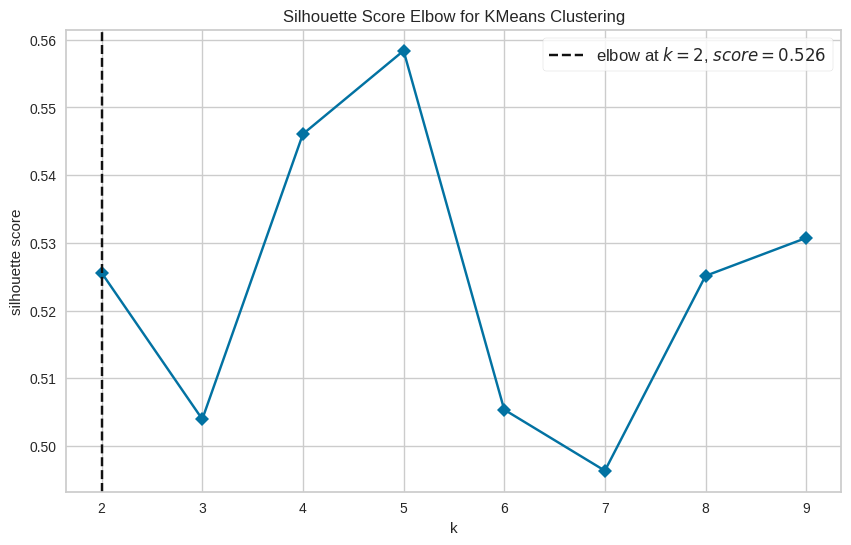

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import numpy as np

df_sampled = df_business.sample(frac=0.1, random_state=42)

feature = ['stars', 'review_count','is_open']
scaler = StandardScaler()
df_business_scaled = scaler.fit_transform(df_sampled[feature])

kmeans = KMeans(n_init=5, random_state=42)
plt.figure(figsize=(10, 6))
visualizer = KElbowVisualizer(kmeans, k=(2,10), metric="silhouette", timings=False)

visualizer.fit(df_business_scaled)
visualizer.show()

**We drop the latitude and longitude, which improves the aggregation effect**

In [49]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
df_sampled['cluster'] = kmeans.fit_predict(df_business_scaled)
cluster_summary = df_sampled.groupby('cluster')[feature].mean()
cluster_summary

,stars,review_count,is_open
cluster,,,
0,4.200467,30.764546,1.000000
1,3.512948,31.398074,0.000000
2,4.090909,1590.212121,0.969697
3,2.385995,24.041456,1.000000
4,3.944118,385.288235,0.943137


In [50]:
from sklearn.metrics import silhouette_score
silhouette_kmean_score = silhouette_score(df_business_scaled, kmeans.labels_)
print(f"Silhouette Score for K-Means: {silhouette_kmean_score}")

Silhouette Score for K-Means: 0.5583861801458097


**Hierarchy**

In [52]:
df_business = df_sampled.drop(columns=['cluster'])

In [53]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

sc = StandardScaler()
numerical_features = df_business.select_dtypes(include=['number']).columns
df_business_scaled = sc.fit_transform(df_business[numerical_features])

df_business_scores = pd.DataFrame(columns=['num_clusters', 'silhouette_score'])

z = linkage(df_business_scaled, method='ward')
for num_clusters in range(2, 10):
    labels = fcluster(z, num_clusters, criterion='maxclust')
    score = silhouette_score(df_business_scaled, labels)
    df_business_scores = pd.concat([df_business_scores, pd.DataFrame([[num_clusters, score]], columns=['num_clusters', 'silhouette_score'])], ignore_index=True)
    print("# cluster = ", num_clusters)

<ipython-input-53-2ab8b467a013>:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_business_scores = pd.concat([df_business_scores, pd.DataFrame([[num_clusters, score]], columns=['num_clusters', 'silhouette_score'])], ignore_index=True)


# cluster =  2
# cluster =  3
# cluster =  4
# cluster =  5
# cluster =  6
# cluster =  7
# cluster =  8
# cluster =  9


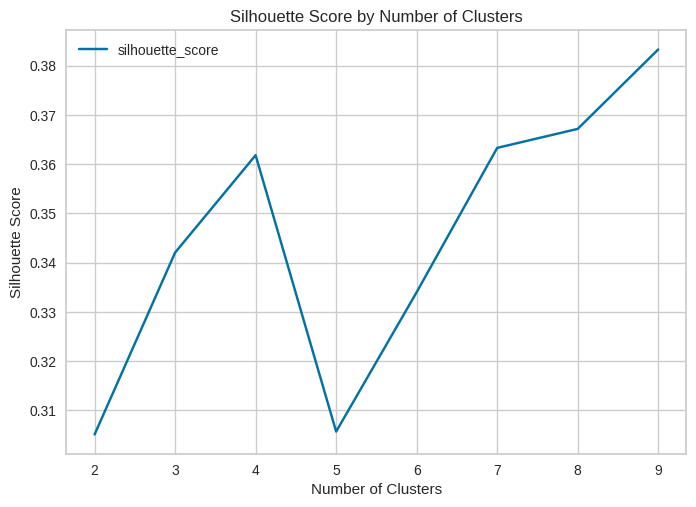

In [54]:
import matplotlib.pyplot as plt
import matplotlib as mpl

df_business_scores.plot.line(x='num_clusters', y='silhouette_score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.show()

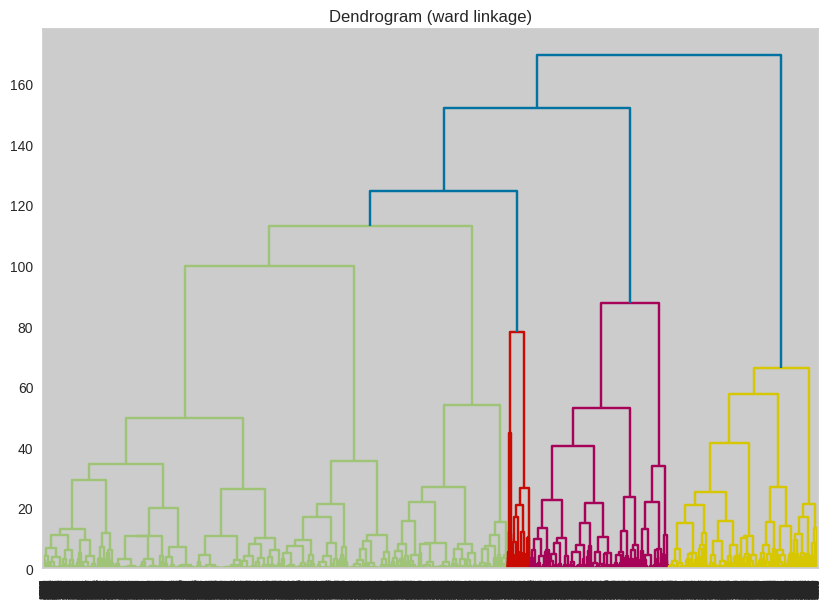

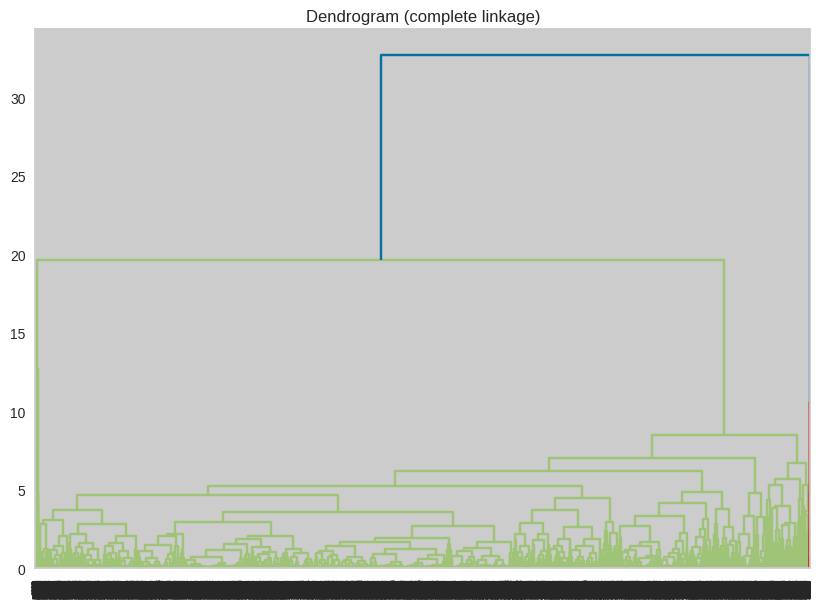

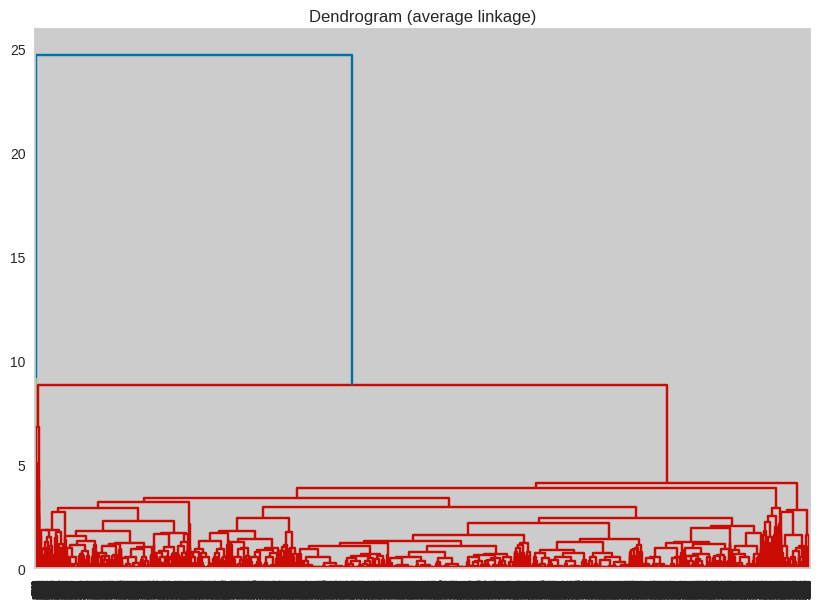

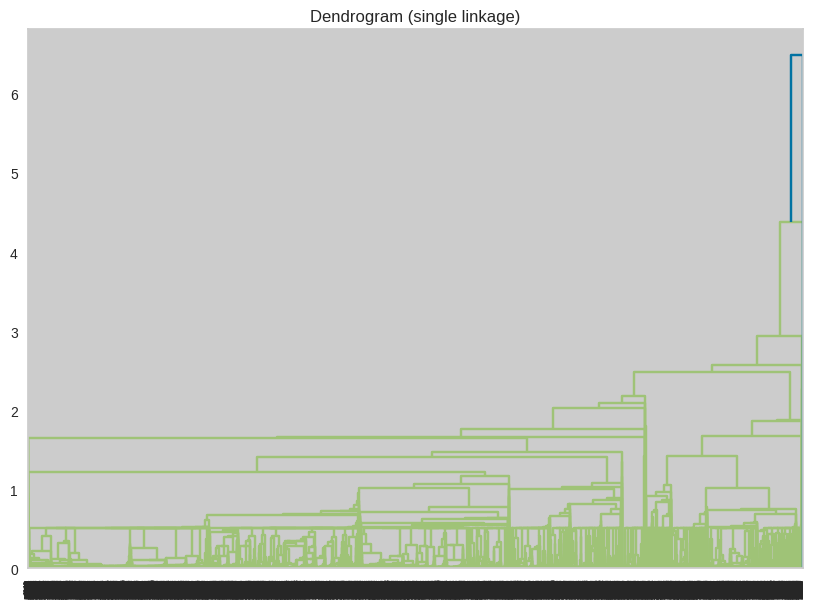

In [55]:
methods = ['ward', 'complete', 'average','single']
for method in methods:
    linked = linkage(df_business_scaled, method=method)
    plt.figure(figsize=(10, 7))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    plt.title(f'Dendrogram ({method} linkage)')
    plt.show()

In [56]:
n_clusters = 9
linkage_matrix = linkage(df_business_scaled, method='ward')
df_business['hierarchical_cluster'] = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
hierarchical_cluster_summary_numeric = df_business.groupby('hierarchical_cluster')[feature].mean()
hierarchical_cluster_summary_numeric

,stars,review_count,is_open
hierarchical_cluster,,,
1,3.542857,32.140816,0.000000
2,3.523505,34.497320,0.000000
3,3.440141,20.385563,0.797535
4,3.748699,32.123994,1.000000
5,3.870112,397.689944,0.972067
6,4.043860,1273.087719,0.964912
7,2.167403,21.861749,1.000000
8,4.067303,32.157895,1.000000
9,4.055929,34.486018,1.000000


In [57]:
hiera_silhouette_avg= silhouette_score(df_business_scaled, df_business['hierarchical_cluster'])
print("Silhouette Score of hierarchical(n_cluster = 9):", hiera_silhouette_avg)
print("Silhouette Score of K Means:", silhouette_kmean_score)

Silhouette Score of hierarchical(n_cluster = 9): 0.3833148848824028
Silhouette Score of K Means: 0.5583861801458097


**Compared to hierarchical, k-mean is better, so at this stage, we choose k-mean**

# **User data**

**PCA**

In [88]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

numerical_cols = df_user.select_dtypes(include=[np.number]).columns
df_numerical = df_user[numerical_cols]

sc = StandardScaler()
normalized_data = sc.fit_transform(df_numerical)

model = PCA()
model.fit(normalized_data)
cumulative_variance = np.cumsum(model.explained_variance_ratio_)

n_components = np.argmax(cumulative_variance >= 0.90) + 1
print("Number of principal components needed to explain 90% of the variance:", n_components)

Number of principal components needed to explain 90% of the variance: 5


In [89]:
model = PCA(n_components=n_components)
transformed_data = model.fit_transform(normalized_data)
transformed_data = pd.DataFrame(transformed_data, columns=[f'PC{i+1}' for i in range(n_components)])
transformed_data.head()

,PC1,PC2,PC3,PC4,PC5
0,22.629734,-9.298640,6.955020,-2.762271,2.164556
1,156.626783,-89.114143,62.336397,-25.721354,38.579724
2,6.007802,-4.193984,4.867027,-2.077819,2.864979
3,1.720272,-1.345104,2.053181,-0.193083,0.976009
4,0.034934,-0.152681,0.361947,-0.200786,0.269741


In [90]:
components_df = pd.DataFrame(model.components_)
components_df.columns = df_user[numerical_cols].columns
components_df.index = [f"PC{i+1}" for i in range(components_df.shape[0])]
components_df

,review_count,useful,funny,cool,fans,average_stars,compliment_hot,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
PC1,0.127523,0.252294,0.260359,0.254658,0.176618,0.003544,0.274644,0.264638,0.251854,0.225337,0.206778,0.200911,0.265202,0.297734,0.297734,0.297718,0.277832
PC2,-0.277434,-0.318454,-0.277141,-0.301500,-0.287505,-0.013907,-0.022397,0.305547,0.330037,0.378791,0.421070,-0.022193,-0.088290,-0.068829,-0.068829,0.022125,0.170987
PC3,0.558200,0.123583,0.045241,0.060422,0.281292,0.374816,-0.272679,0.156005,0.115211,0.205947,0.243994,-0.310615,-0.180218,-0.220698,-0.220698,-0.028077,-0.082181
PC4,-0.185981,-0.076024,-0.048112,-0.052086,-0.113001,0.924412,0.128141,-0.062945,-0.045015,-0.079363,-0.096974,0.164382,0.069529,0.090204,0.090204,0.007109,0.031714
PC5,0.382794,-0.169175,-0.232569,-0.233998,0.245540,-0.062210,0.254782,-0.020600,-0.029426,0.048690,0.012813,0.725830,-0.144848,-0.081433,-0.081433,-0.082045,-0.123700


In [91]:
print("Cumulative explained variance:", model.explained_variance_ratio_.sum())

Cumulative explained variance: 0.9001268367598557


**K-mean**

In [85]:
pip install yellowbrick

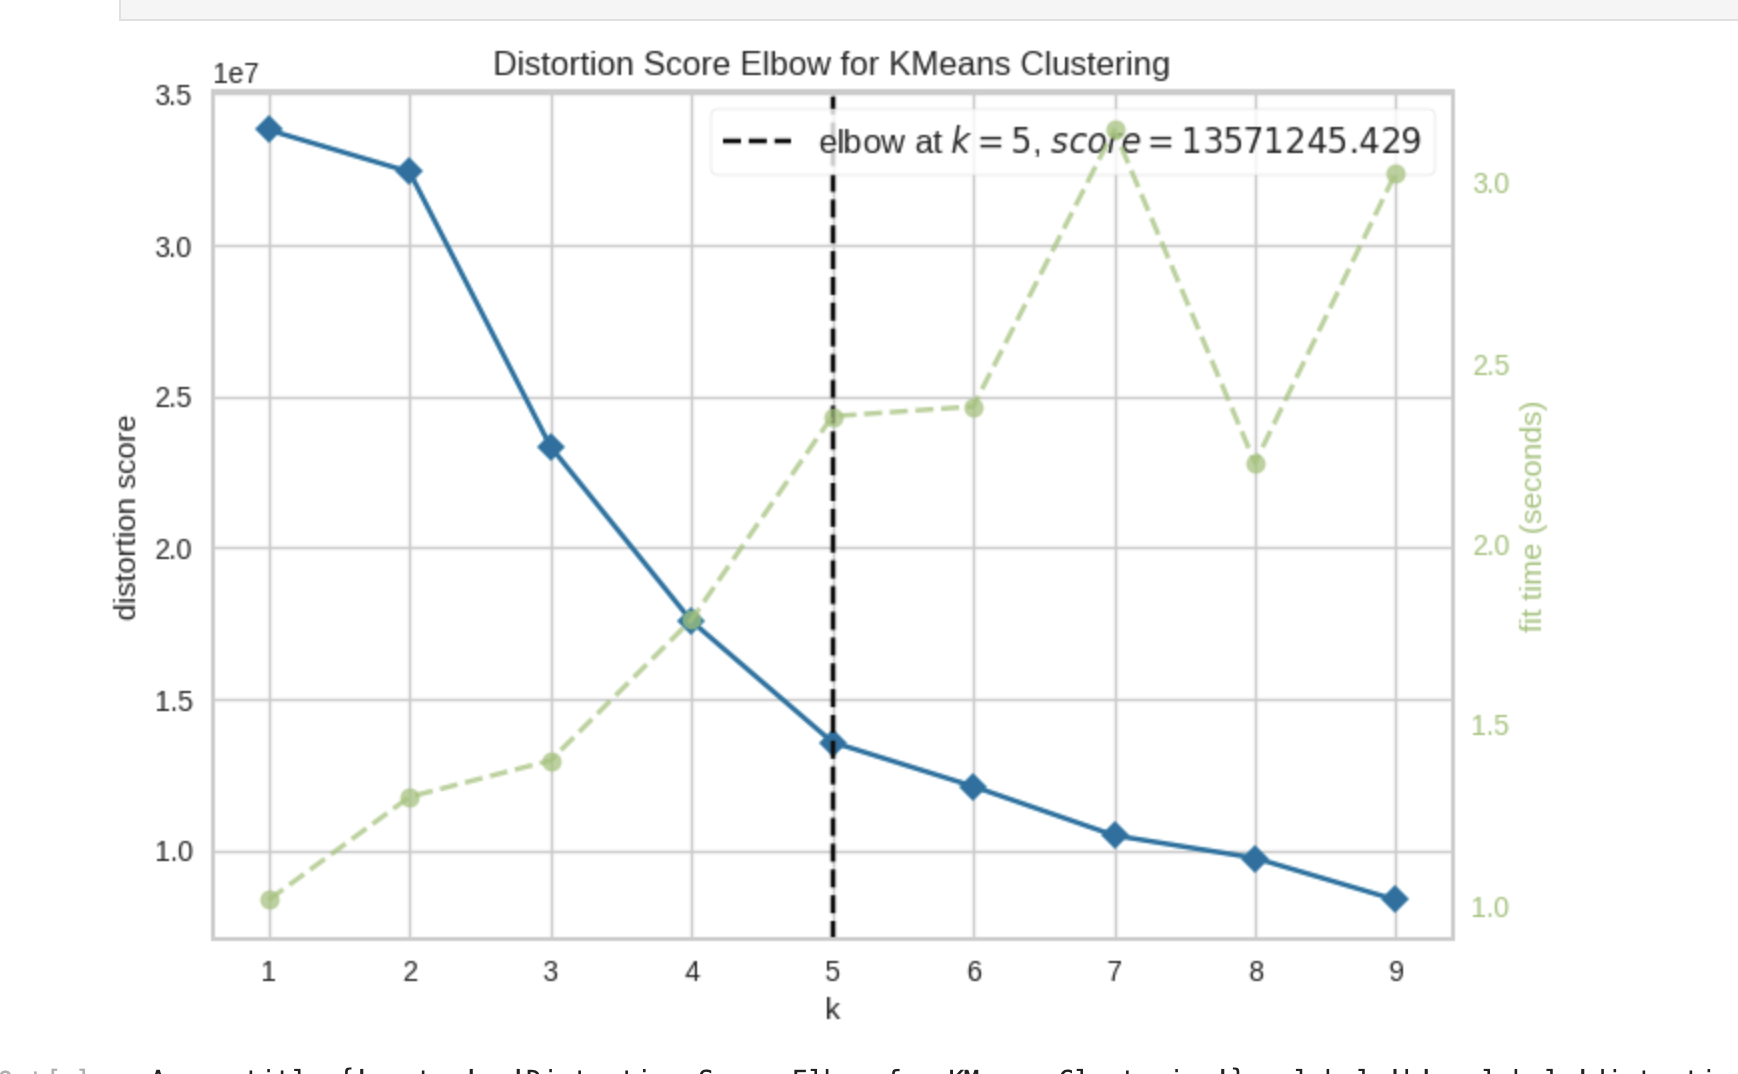

**We completed this step in m1's notebook, see m1 for more details**

**See other notebooks for next steps**